## Imports

In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import contextlib
import io
import imageio

## Functions

In [3]:
class Rosenbrock:
    def __init__(self):
        self.name = "Rosenbrock"
        self.minima= [(1, 1)] # Global minimum of Rosenbrock function
        self.limits = [(-2, 2), (-1, 3)] # Limits for Rosenbrock function

    def evaluate(self, x, y):
        return ((1 - x)**2 + 100*(y - (x**2))**2) # Rosenbrock function 


class Rastrigin: 
    def __init__(self):
        self.name = "Rastrigin"
        self.minima = [(0, 0)] # Global minimum of Rastrigin function
        self.limits = [(-5.12, 5.12), (-5.12, 5.12)] # Limits for Rastrigin function

    def evaluate(self, x, y):
        return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y))) # Rastrigin function
    
class Himmelblau:
    def __init__(self):
        self.name   = "Himmelblau"
        self.minima = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)] # Global minima of Himmelblau function
        self.limits = [(-6, 6), (-6, 6)] # Limits for Himmelblau function

    def evaluate(self, x, y):
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2 # Himmelblau function
    
class Beale:
    def __init__(self):
        self.name   = "Beale"
        self.minima = [(3, 0.5)] # Global minimum of Beale function
        self.limits = [(-4, 4), (-4, 4)] # Limits for Beale function

    def evaluate(self, x, y):
        return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2 # Beale function

In [4]:
def lectura(filepath: str):
    df = pd.read_csv(filepath, sep=None, engine='python') 
    df.columns = df.columns.str.strip() #Clean column names by stripping whitespace
    print(f"Detected columns: {list(df.columns)}")

    val_x = df.iloc[:, 1] # Extract values from the second column (X) using .iloc, which is where the X values are located
    val_y = df.iloc[:, 2] # Extract values from the third column (Y) using .iloc, which is where the Y values are located

    return val_x, val_y, df

In [5]:
def plot_round(val_x, val_y, function, round: str): #, save_figure: bool = False): 

    ###-PLOT-###
    # Create the background map of the function 
    x_range = np.linspace(function.limits[0][0], function.limits[0][1], 400)
    y_range = np.linspace(function.limits[1][0], function.limits[1][1], 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = function.evaluate(X_mesh, Y_mesh)

    # Create the contour plot
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(vmin=0.01, vmax=10**5), cmap='viridis', alpha=0.8)
    plt.colorbar(label=f'{function.name} value')

    # Draw the explored points
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Explored points')

    # Draw the white contour lines of the points
    #plt.contour(X_mesh, Y_mesh, Z_mesh, levels=15, colors='white', linewidths=0.5, alpha=0.8)

    # Add labels to the points
    #for i, row in df.iterrows():
    #  plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title(f"Round {round}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    return plt


## Main

### Evaluation

In [6]:
def evaluation(function, folder_path, save_plot: bool=False):

    csvs = [f for f in os.listdir(folder_path) if f.endswith('.csv') and f.startswith(f'{function.name}') and "RESULT" not in f and "plot" not in f]
    csvs = sorted(csvs, key=lambda f: int(f.split('_')[-1].replace('.csv', '').replace('R', '')))
    for file in csvs:
        full_path = os.path.join(folder_path, file)
        round       = int(file.split('_')[-1].replace('.csv', '').replace('R', '')) 
        output_file = f"{function.name}_R{round}_RESULT.csv"
        plot_file   = f"{function.name}_R{round}_plot.jpg"
        

        print("-" * 30)
        print(f"Processing file: {file}")
        print(f"Saving output to {output_file}")
        print(f"Saving plot to {plot_file}")
        print(f"Round: {round}")
        print("-" * 30)

        val_x, val_y, df = lectura(full_path)

    
        df['real'] = function.evaluate(val_x, val_y) # Calculate the function value for each (X, Y) pair and store it in a new column called 'real'

        if 'eval' in df.columns:
            # MAE
            df['Punctual_Abs_Error'] = np.abs(df['eval'] - df['real'])
            
            # MRE
            df['Punctual_Rel_Error_%'] = np.where(
                df['real'] != 0, 
                (df['Punctual_Abs_Error'] / np.abs(df['real'])) * 100, 
                0.0
            )

        df.to_csv(os.path.join(folder_path, output_file), index=False)

        print(df.head()) 
        plt = plot_round(val_x, val_y, function, str(round))

        if save_plot:
            plt.savefig(os.path.join(folder_path, plot_file), dpi=300, bbox_inches='tight')
            print(f"Plot saved correctly as: {plot_file}")

### Metrics (MAE + MRE + Distance values)

In [7]:
def metrics(function, folder_path):

    csvs_results = [f for f in os.listdir(folder_path) if f.endswith('RESULT.csv') and f.startswith(f'{function.name}')]
    csvs_results = sorted(csvs_results, key=lambda f: int(f.split('_')[-2].replace('.csv', '').replace('R', '')))

    summary_csv = []
    for file in csvs_results:
        file_path = os.path.join(folder_path, file)

        val_x, val_y, df = lectura(file_path) # Data lecture

        # Calculate the distance of each point to the global minimum of the function and
        # store these distances in new columns in the DataFrame
        for i, (mx, my) in enumerate(function.minima, 1):
            df[f'M{i}'] = np.sqrt((val_x - mx)**2 + (val_y - my)**2)

        # Calculate the Mean Absolute Error (MAE) and Mean Relative Error (MRE)
        if 'eval' in df.columns and 'real' in df.columns:
            if 'Punctual_Abs_Error' not in df.columns:
                df['Punctual_Abs_Error'] = np.abs(df['eval'] - df['real'])
            
            if 'Punctual_Rel_Error_%' not in df.columns:
                df['Punctual_Rel_Error_%'] = np.where(df['real'] != 0, (df['Punctual_Abs_Error'] / np.abs(df['real'])) * 100, 0.0)
            
            final_mae = df['Punctual_Abs_Error'].mean()
            final_mre = df['Punctual_Rel_Error_%'].mean()
        else:
            final_mae = 0
            final_mre = 0

        round_name = [p for p in file.split('_') if p.startswith('R') and p[1:].isdigit()][0]
    
        row = {
            'Function': function.name,
            'Round': round_name,
            'MAE': final_mae, 
            'MRE': final_mre, 
        }

        for i in range(len(function.minima)):
            row[f'Distance_M{i+1}'] = df[f'M{i+1}'].min()
        
        summary_csv.append(row)

        print(f"Function: {function.name}. Ronda: {round_name}. MAE: {final_mae:.4f}. MRE: {final_mre:.4f}")

    # Final CSV with all results
    return pd.DataFrame(summary_csv)

### Plots

In [8]:
def create_gif(function, folder_path):
    images_files = [f for f in os.listdir(folder_path) if f.endswith('_plot.jpg') and f.startswith(f'{function.name}')]
    
    if not images_files:
        print(f"Did not find images to create the GIF for {function.name}.")
        return

    images_files = sorted(images_files, key=lambda f: int(f.split('_')[-2].replace('R', ''))) #order by round number extracted from filename
    
    images = []
    for file in images_files:
        file_path = os.path.join(folder_path, file)
        images.append(imageio.imread(file_path))
    
    gif_name = f"{function.name}.gif"
    gif_path = os.path.join(folder_path, gif_name)
    
    imageio.mimsave(gif_path, images, duration=300, loop=0) # duration is the seconds per frame (bigger value, slower), loop=0 means it will loop indefinitely
    print(f"¡GIF created correctly for {function.name} at: {gif_name}!")

Processing function: Himmelblau
------------------------------
Processing file: Himmelblau_R0.csv
Saving output to Himmelblau_R0_RESULT.csv
Saving plot to Himmelblau_R0_plot.jpg
Round: 0
------------------------------
Detected columns: ['RUN', 'X', 'Y']
   RUN     X        Y        real
0    1  1.02  0.60000  119.186512
1    2  1.08  6.00000  919.502889
2    3 -3.00  1.86000   42.796432
3    4 -6.00 -1.20000  700.073600
4    5 -6.00 -5.23437  598.000655
Plot saved correctly as: Himmelblau_R0_plot.jpg
------------------------------
Processing file: Himmelblau_R1.csv
Saving output to Himmelblau_R1_RESULT.csv
Saving plot to Himmelblau_R1_plot.jpg
Round: 1
------------------------------
Detected columns: ['Number', 'X', 'Y', 'eval']
   Number      X      Y      eval        real  Punctual_Abs_Error  \
0       1 -3.112  1.389  -138.447   66.961644          205.408644   
1       2 -0.423 -4.576   -98.111  419.773029          517.884029   
2       3  0.420 -2.480  -691.826  177.170329         

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24432\692478124.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


¡GIF created correctly for Himmelblau at: Himmelblau.gif!
Processing function: Rosenbrock
------------------------------
Processing file: Rosenbrock_R0.csv
Saving output to Rosenbrock_R0_RESULT.csv
Saving plot to Rosenbrock_R0_plot.jpg
Round: 0
------------------------------
Detected columns: ['RUN', 'X', 'Y']
   RUN         X         Y         real
0    1 -2.000000 -0.460000  1998.160000
1    2  2.000000 -0.920000  2421.640000
2    3  0.593515 -1.000000   183.025956
3    4  1.381050  3.000000   119.544724
4    5  2.000000  0.488566  1234.016874
Plot saved correctly as: Rosenbrock_R0_plot.jpg
------------------------------
Processing file: Rosenbrock_R1.csv
Saving output to Rosenbrock_R1_RESULT.csv
Saving plot to Rosenbrock_R1_plot.jpg
Round: 1
------------------------------
Detected columns: ['Number', 'X', 'Y', 'eval']
   Number      X      Y     eval       real  Punctual_Abs_Error  \
0       1  0.420 -0.516 -314.071  48.278176          362.349176   
1       2  0.750  1.380  -77.348 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24432\692478124.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


¡GIF created correctly for Rosenbrock at: Rosenbrock.gif!
Processing function: Beale
------------------------------
Processing file: Beale_R0.csv
Saving output to Beale_R0_RESULT.csv
Saving plot to Beale_R0_plot.jpg
Round: 0
------------------------------
Detected columns: ['Run', 'X', 'Y']
   Run     X        Y          real
0    1  0.64 -0.52000      7.048295
1    2 -2.72 -4.00000  33907.443125
2    3  0.64 -4.00000   1662.363125
3    4  4.00  3.00000  12632.203125
4    5  1.20  2.31926    334.631802
Plot saved correctly as: Beale_R0_plot.jpg
------------------------------
Processing file: Beale_R1.csv
Saving output to Beale_R1_RESULT.csv
Saving plot to Beale_R1_plot.jpg
Round: 1
------------------------------
Detected columns: ['Number', 'X', 'Y', 'eval']
   Number      X      Y         eval         real  Punctual_Abs_Error  \
0       1  2.098  1.097  -800772.689    20.934856        8.007936e+05   
1       2  1.200  3.360  -362074.718  2435.655593        3.645104e+05   
2       3  1

...

Plot saved correctly as: Beale_R7_plot.jpg
------------------------------
Processing file: Beale_R8.csv
Saving output to Beale_R8_RESULT.csv
Saving plot to Beale_R8_plot.jpg
Round: 8
------------------------------
Detected columns: ['Number', 'X', 'Y', 'eval']
   Number      X      Y       eval         real  Punctual_Abs_Error  \
0       1  1.957  2.976 -13379.475  3069.413034        16448.888034   
1       2  0.982  0.552 -28372.495     6.849387        28379.344387   
2       3  2.800 -1.300 -18073.405    81.918592        18155.323592   
3       4 -0.180  3.800 -18575.000    51.033263        18626.033263   
4       5 -3.200  0.120 -20438.831    81.696443        20520.527443   

   Punctual_Rel_Error_%  
0            535.896859  
1         414334.047174  
2          22162.641283  
3          36497.829477  
4          25118.018195  
Plot saved correctly as: Beale_R8_plot.jpg
Detected columns: ['Run', 'X', 'Y', 'real']
Function: Beale. Ronda: R0. MAE: 0.0000. MRE: 0.0000
Detected columns

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24432\692478124.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


¡GIF created correctly for Beale at: Beale.gif!
Processing function: Rastrigin
------------------------------
Processing file: Rastrigin_R0.csv
Saving output to Rastrigin_R0_RESULT.csv
Saving plot to Rastrigin_R0_plot.jpg
Round: 0
------------------------------
Detected columns: ['Run', 'X', 'Y']
   Run     X         Y       real
0    1  4.00 -1.120000  19.964714
1    2 -0.60  4.000000  34.450170
2    3 -1.16 -2.240000  20.377027
3    4 -0.52  0.597419  38.732879
4    5  1.12 -4.000000  19.964714
Plot saved correctly as: Rastrigin_R0_plot.jpg
------------------------------
Processing file: Rastrigin_R1.csv
Saving output to Rastrigin_R1_RESULT.csv
Saving plot to Rastrigin_R1_plot.jpg
Round: 1
------------------------------
Detected columns: ['Number', 'X', 'Y', 'eval']
   Number      X      Y    eval       real  Punctual_Abs_Error  \
0       1 -1.171 -1.901  18.377  12.095718            6.281282   
1       2 -3.850 -1.165  17.136  25.211458            8.075458   
2       3 -0.360 -1.440

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24432\692478124.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


¡GIF created correctly for Rastrigin at: Rastrigin.gif!


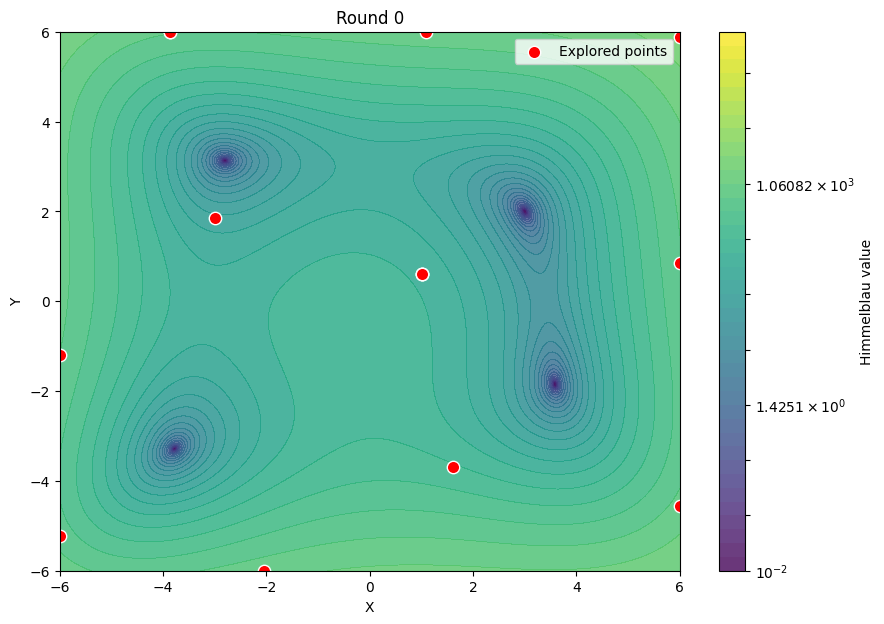

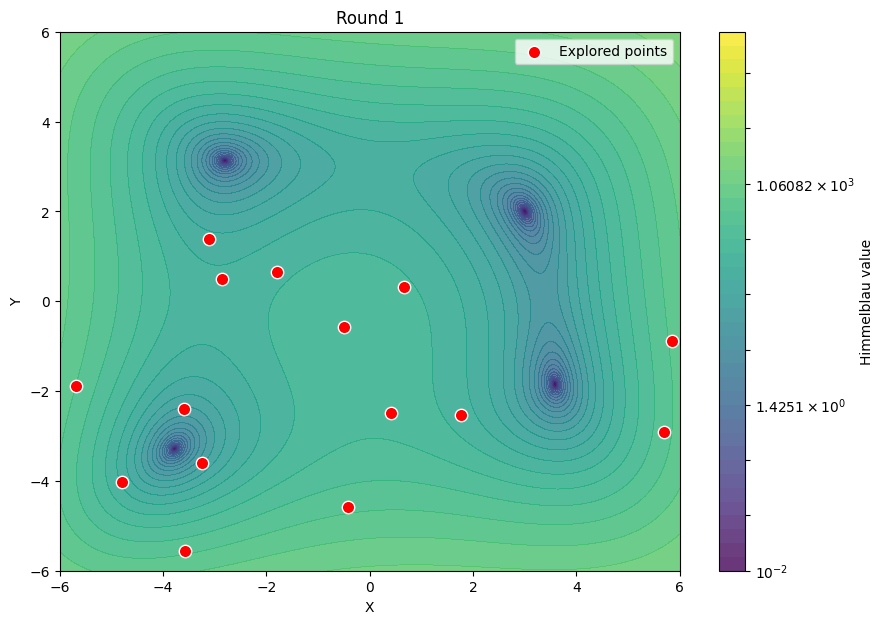

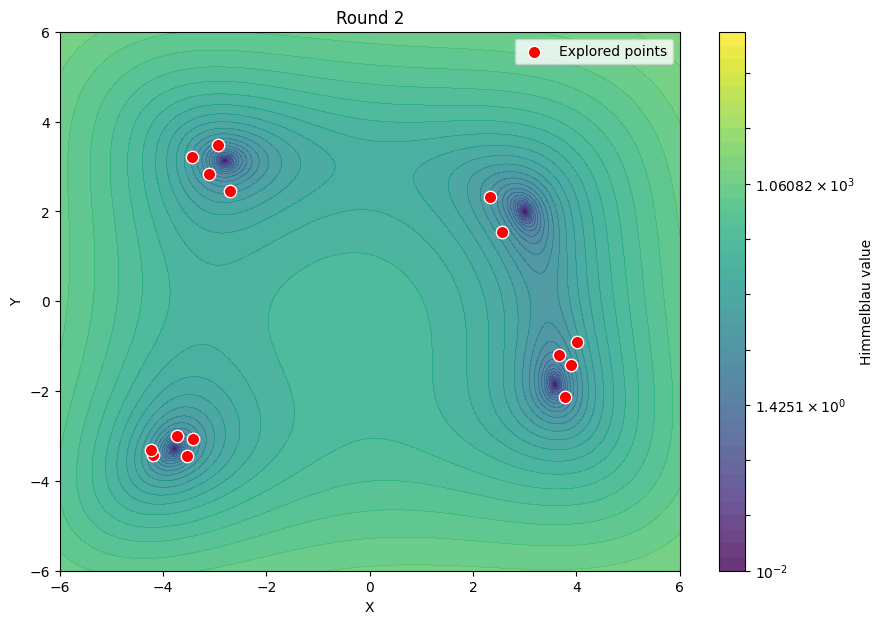

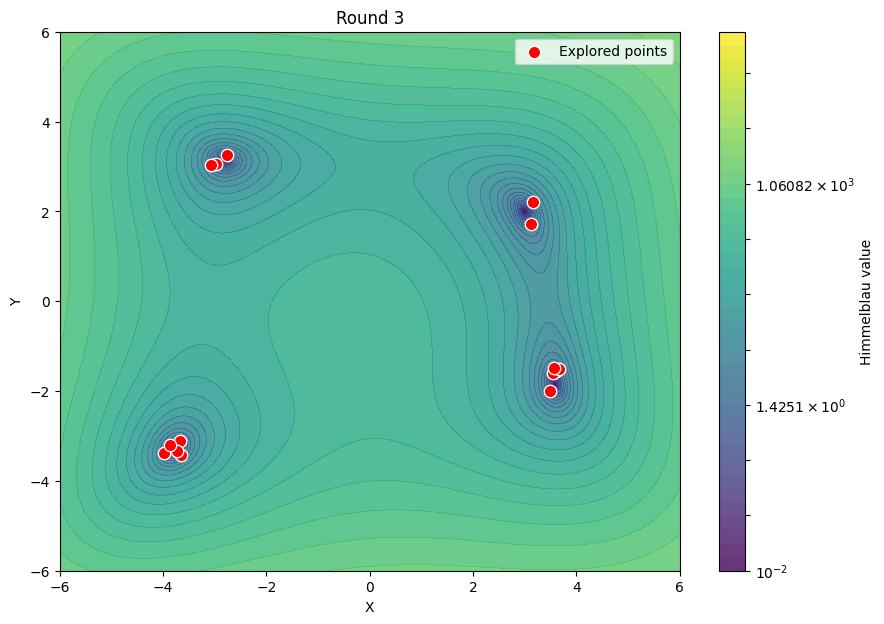

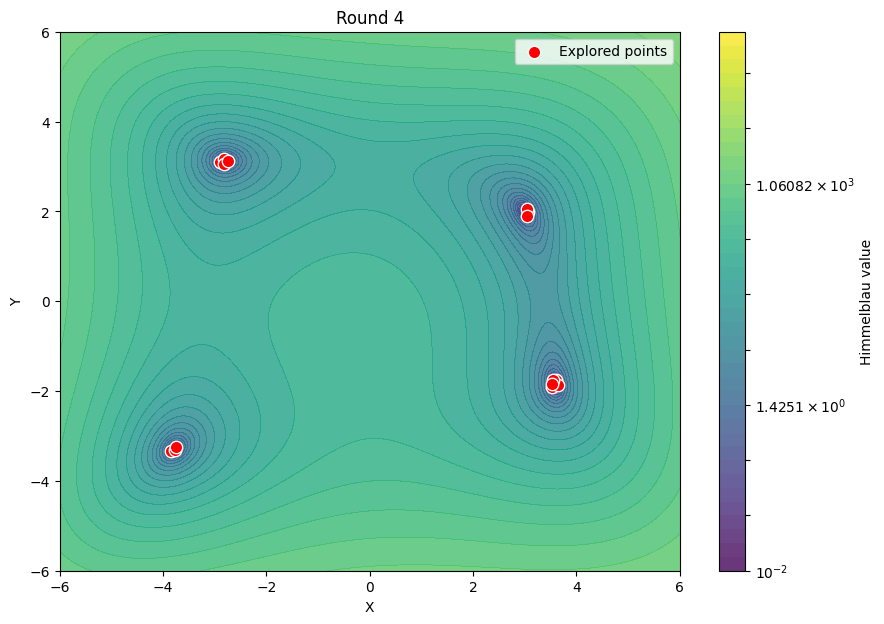

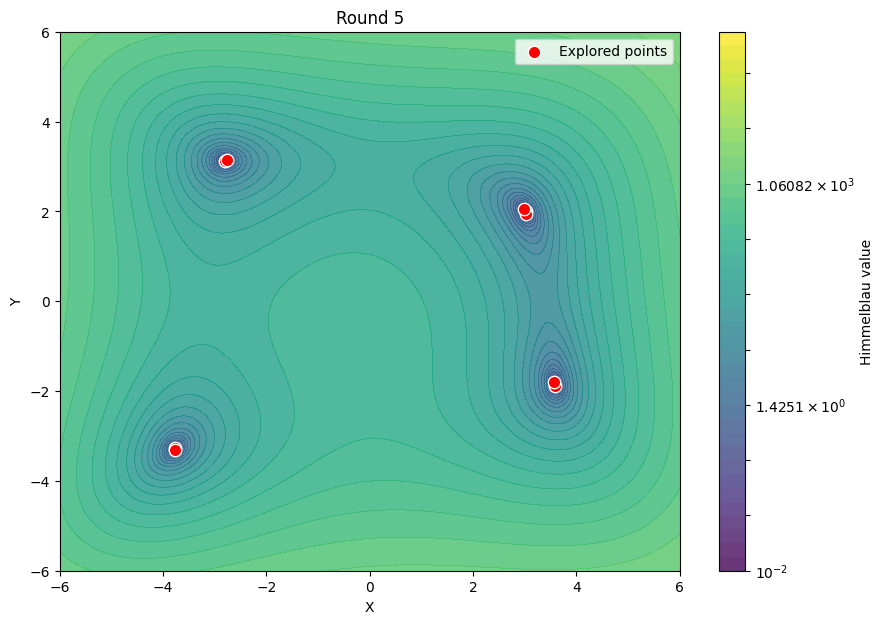

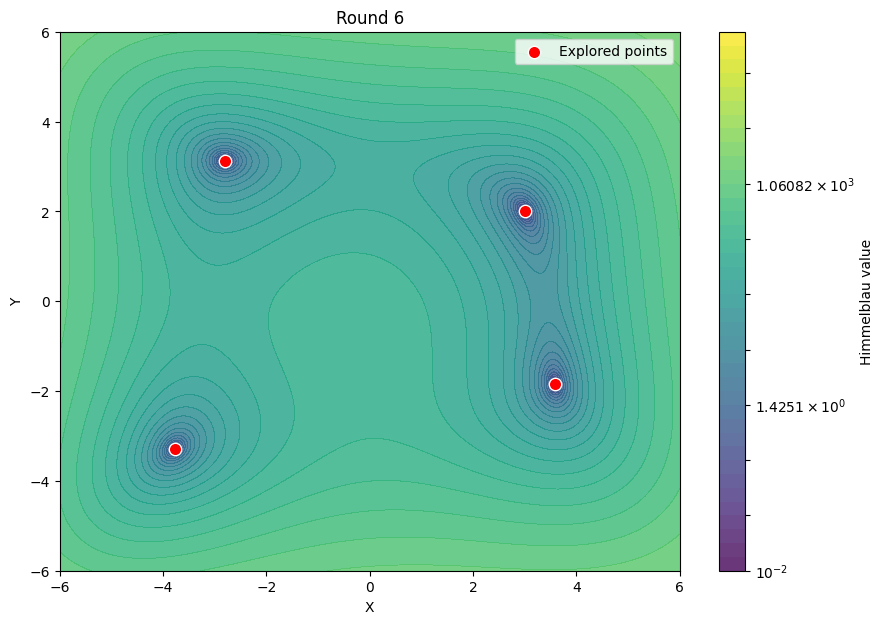

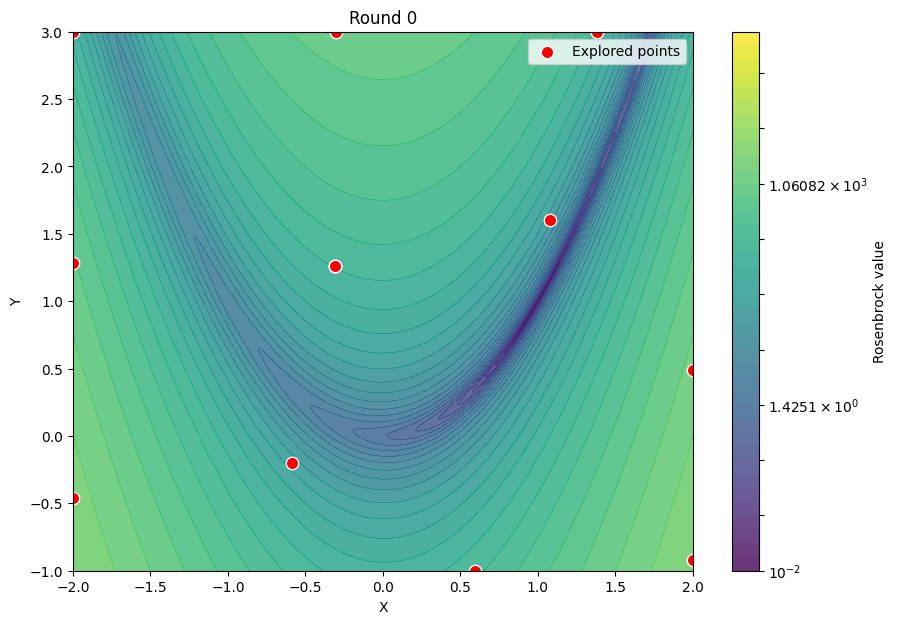

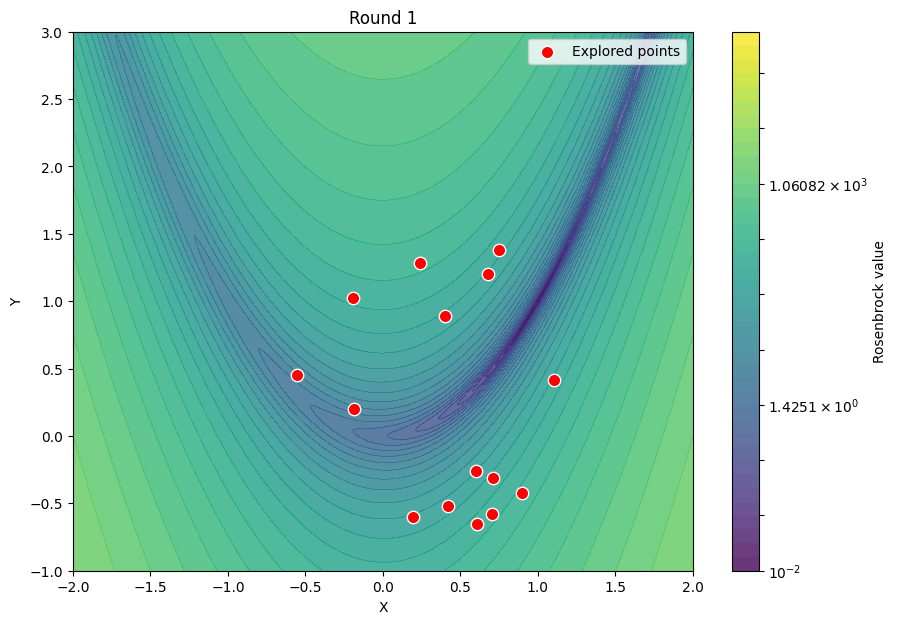

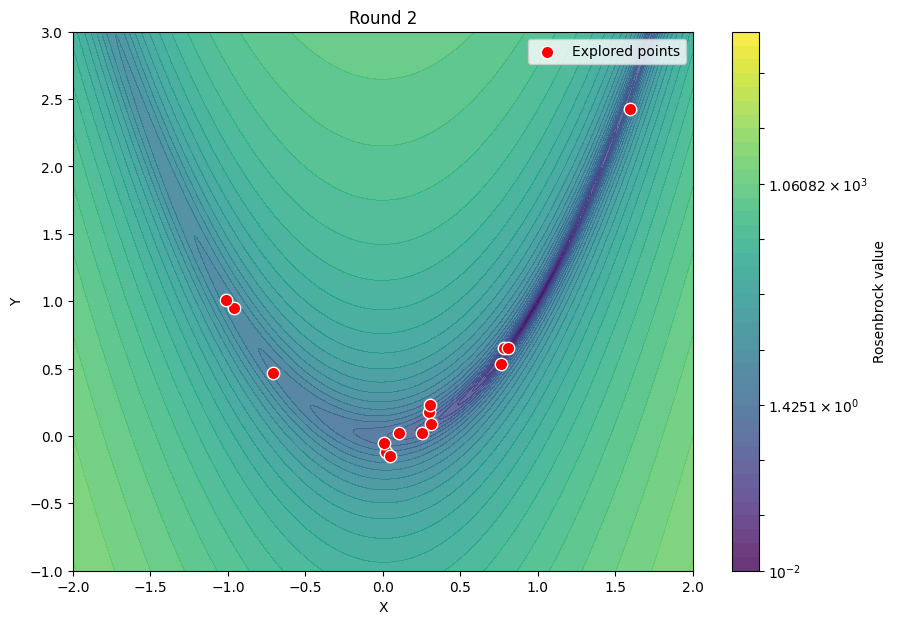

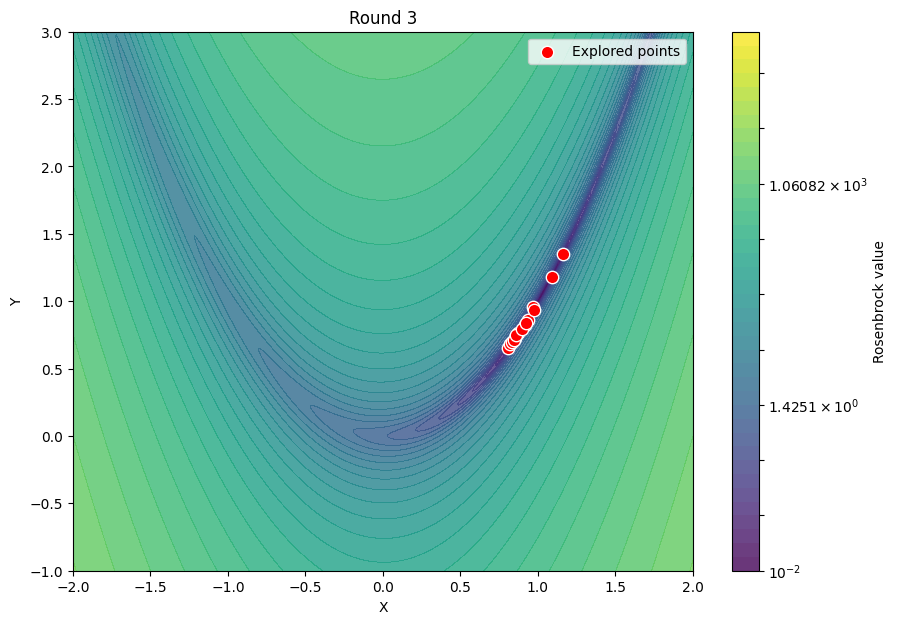

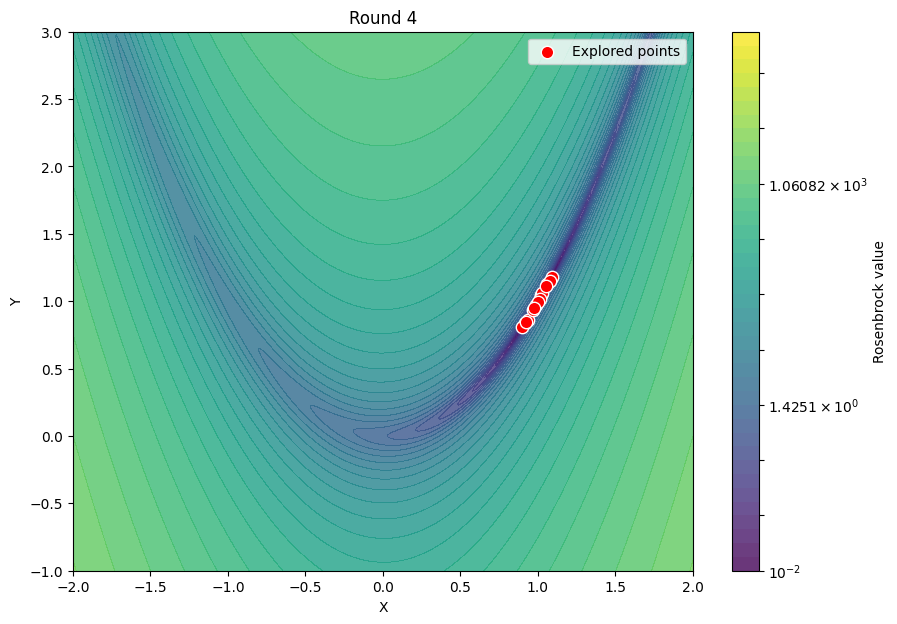

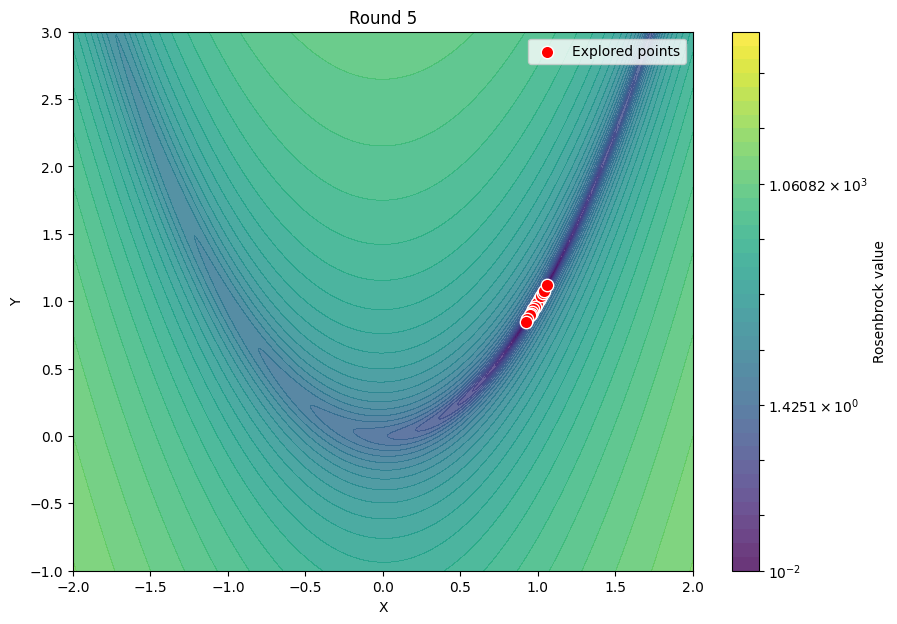

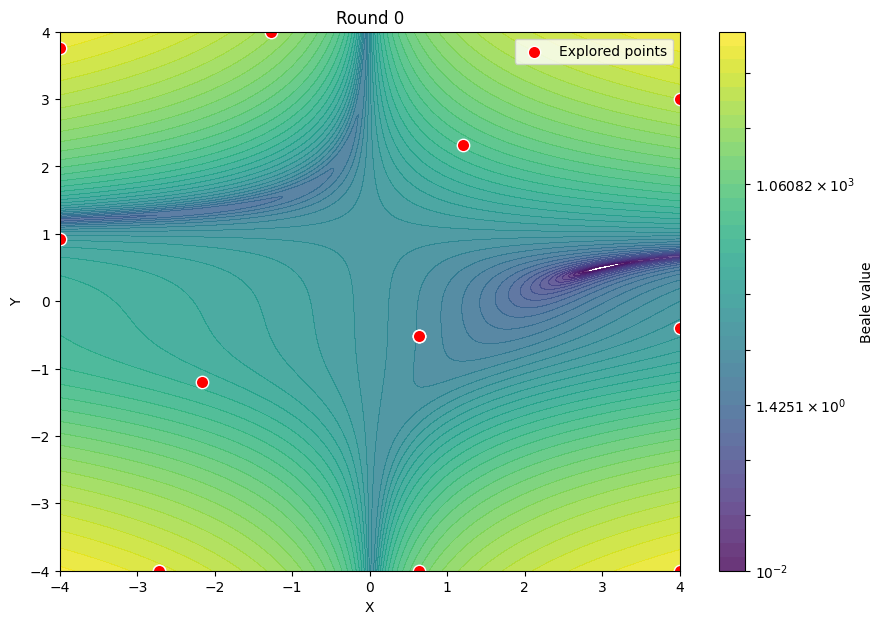

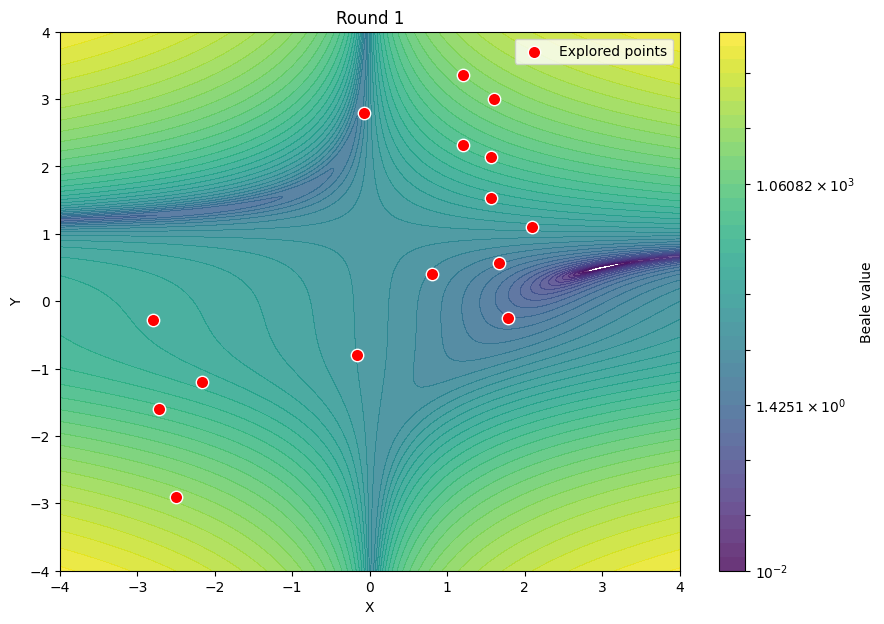

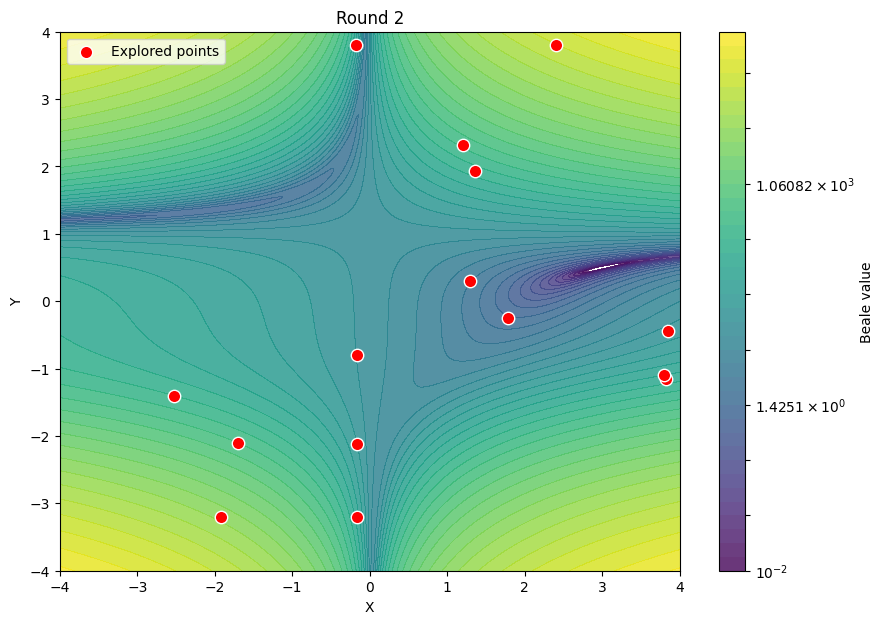

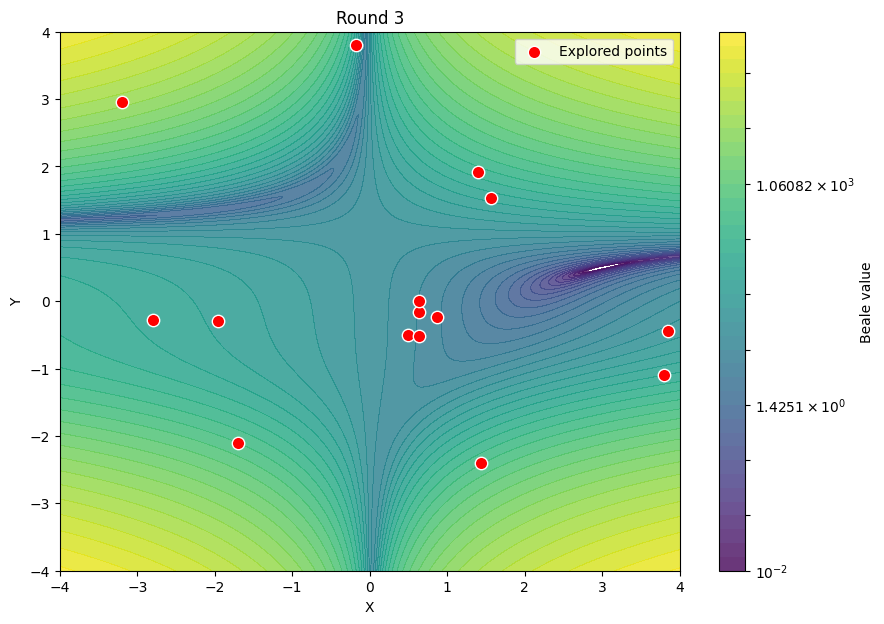

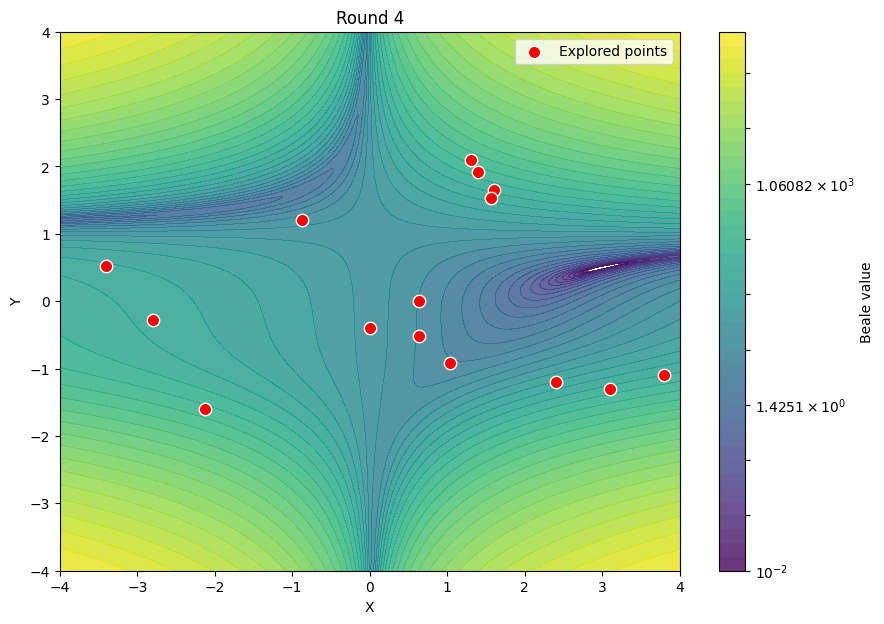

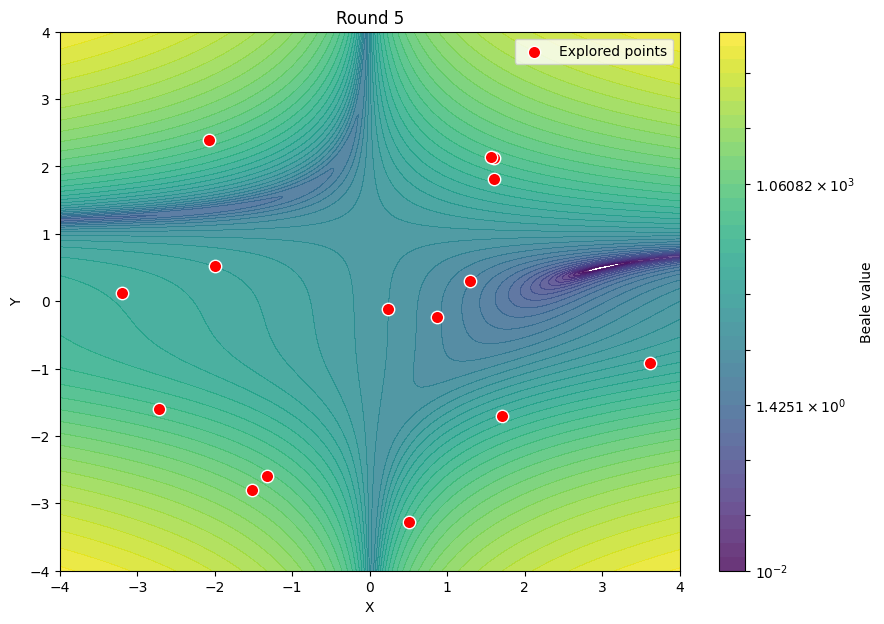

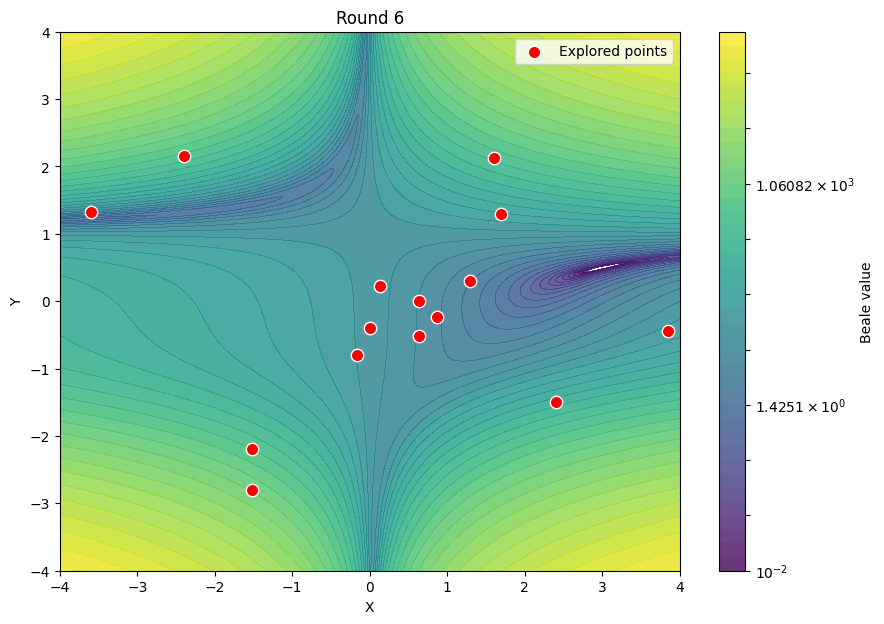

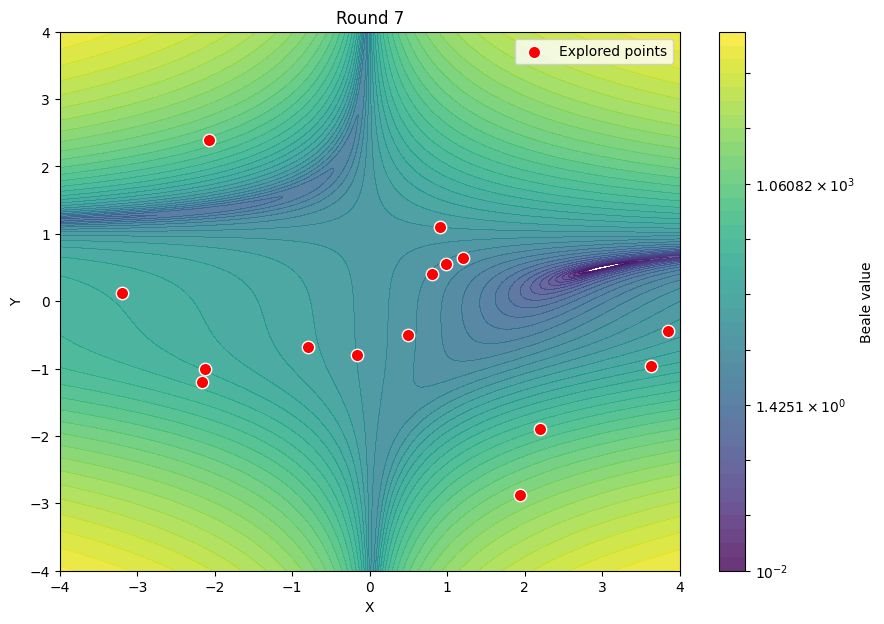

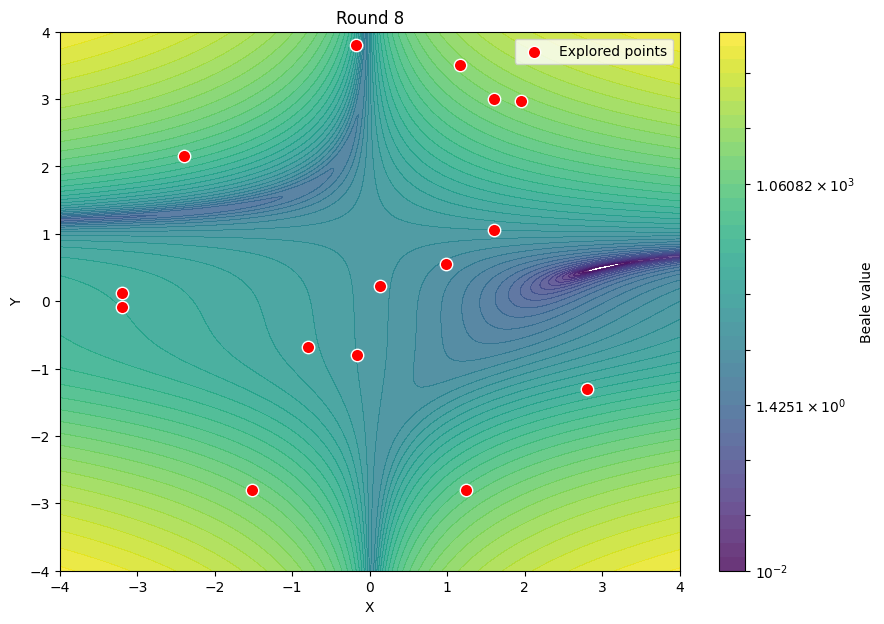

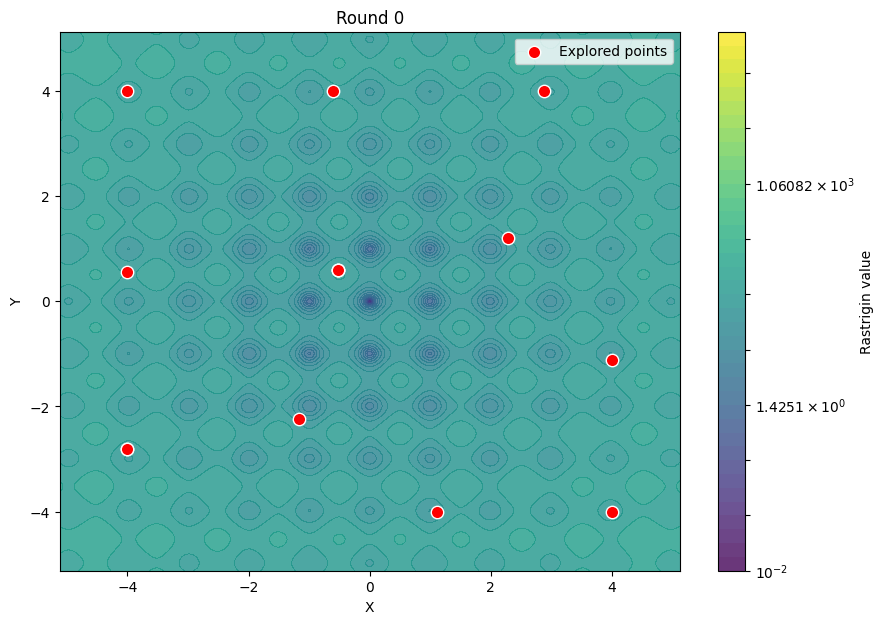

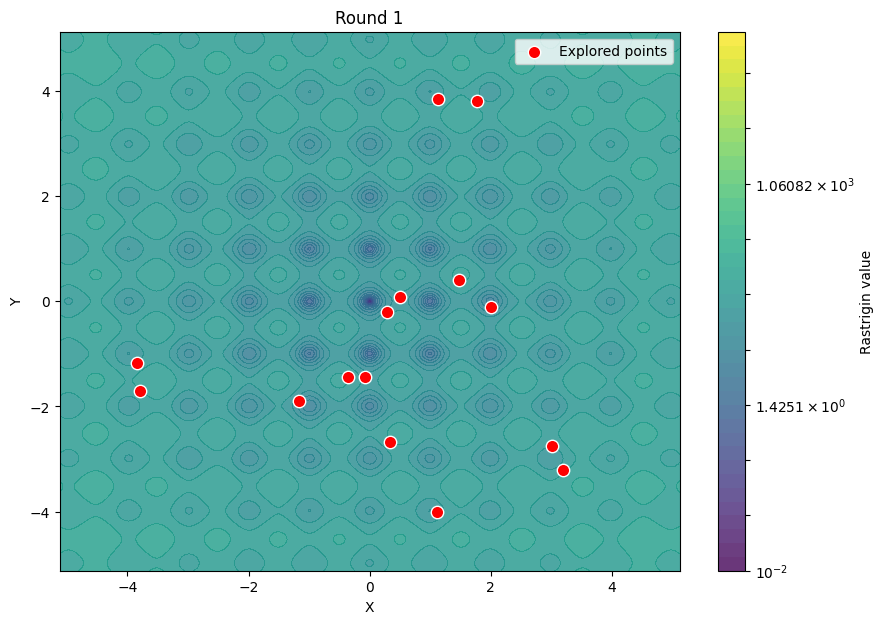

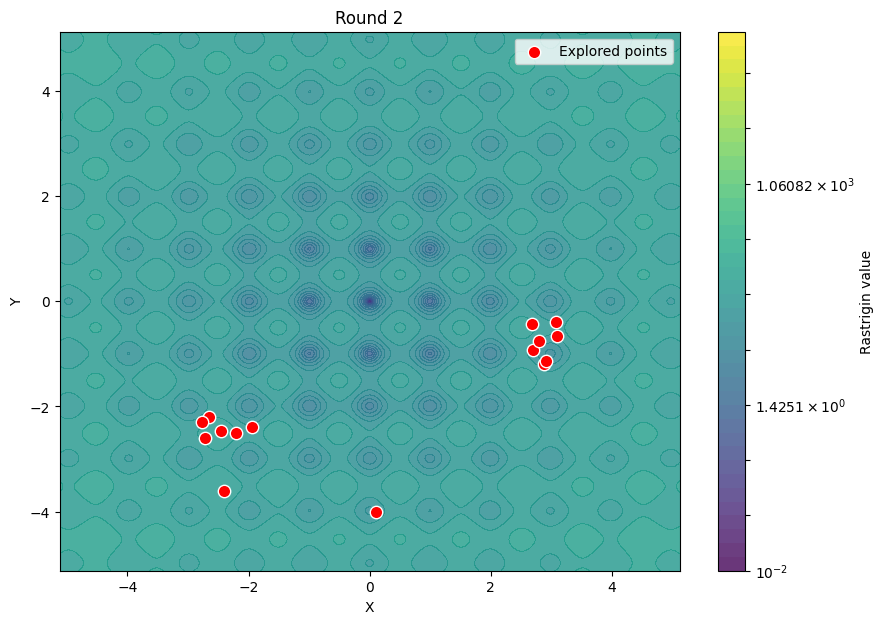

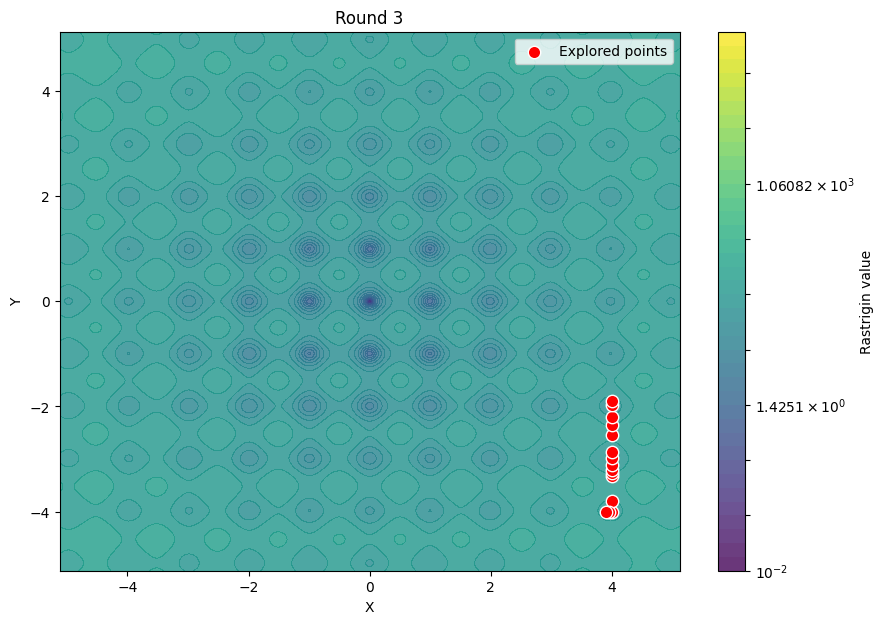

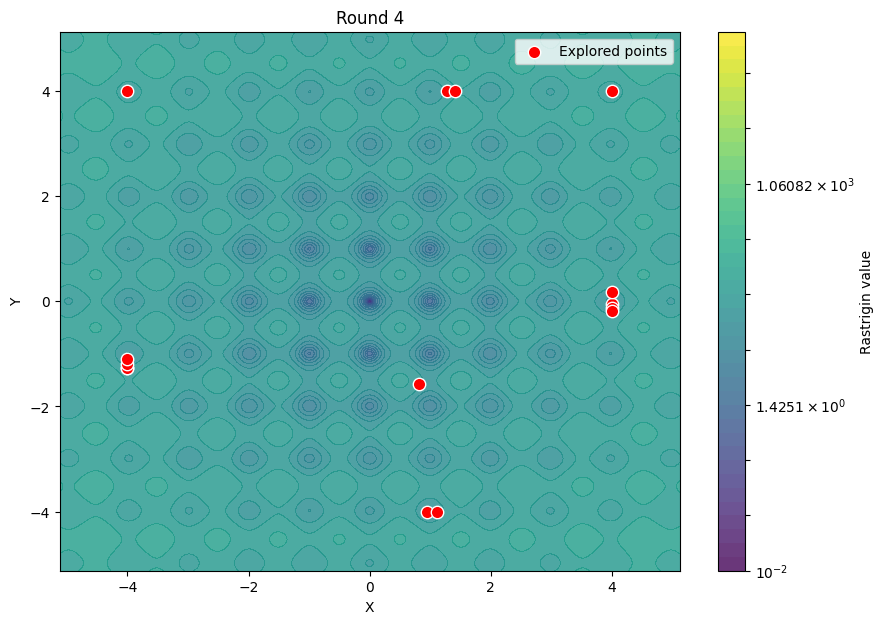

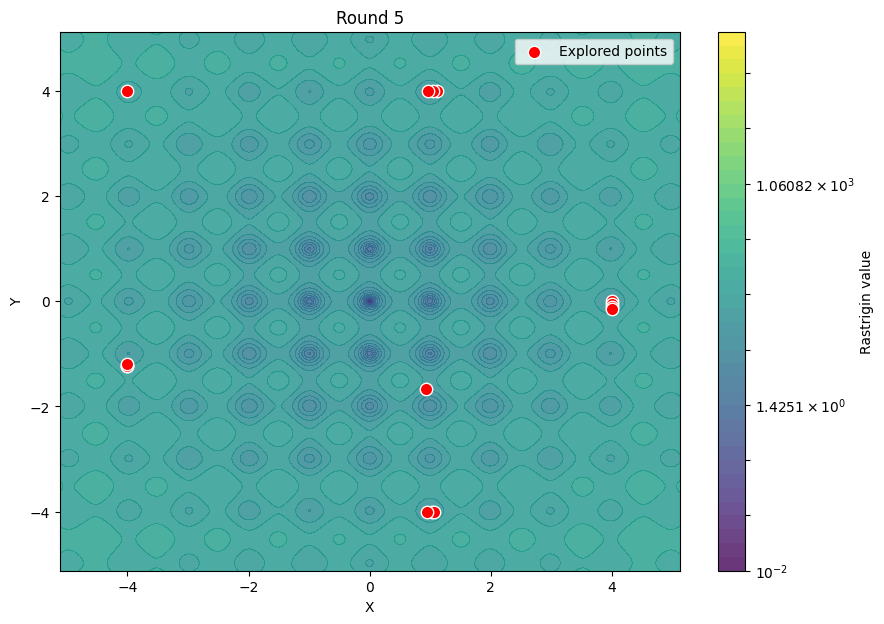

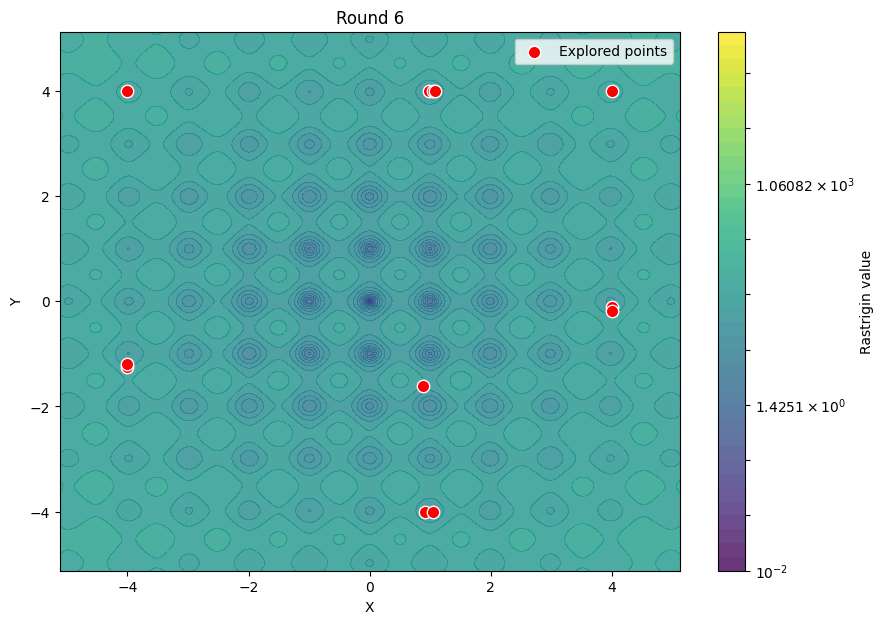

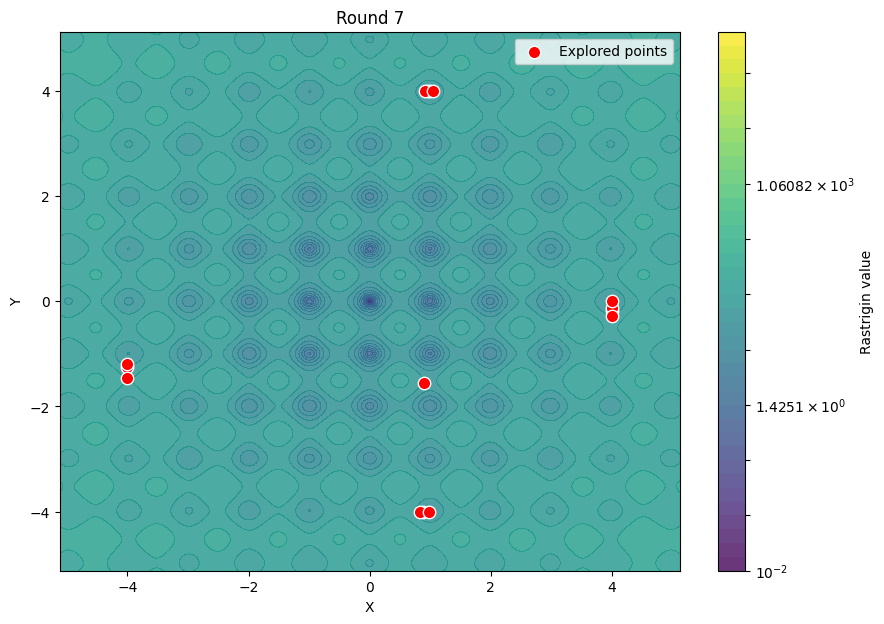

In [9]:
functions = [Himmelblau(), Rosenbrock(), Beale(), Rastrigin()]

BASE_DIR = os.getcwd()

all_results = []

for function in functions:
    folder_path = os.path.join(BASE_DIR, function.name)

    if os.path.exists(folder_path):
        print(f"Processing function: {function.name}")
        evaluation(function, folder_path, save_plot=True)
        df_metrics = metrics(function, folder_path)
        all_results.append(df_metrics)
        create_gif(function, folder_path)



## Summary 

### Results summary table

In [10]:
print([type(x) for x in all_results])

all_results = [df for df in all_results if df is not None and not df.empty] #eliminate empty DataFrames

final_table = pd.concat(all_results, ignore_index=True) #join all the results 

final_table['Round'] = final_table['Round'].astype(str)

final_table['Round'] = pd.to_numeric(
    final_table['Round'].str.extract('R(\\d+)')[0],
    errors='coerce'
)

final_table = final_table.sort_values(['Function', 'Round']).reset_index(drop=True)

# eliminate column 'round_number' (no longer needed)
if 'round_number' in final_table.columns:
    final_table = final_table.drop(columns=['round_number'])

final_table = final_table.round(2)

final_path = os.path.join(BASE_DIR, "Analysis_summary.csv")
final_table.to_csv(final_path, index=False)

print("\n Summary table:")
display(final_table) 


# Save table as png
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

tabla = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.auto_set_column_width(col=list(range(len(final_table.columns))))


plt.close()



[<class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>, <class 'pandas.DataFrame'>]

 Summary table:


,Function,Round,MAE,MRE,Distance_M1,Distance_M2,Distance_M3,Distance_M4
0,Beale,0,0.00,0.00,1.35,NaN,NaN,NaN
1,Beale,1,950732.45,7182061.13,1.08,NaN,NaN,NaN
2,Beale,2,371118.17,553752.37,1.27,NaN,NaN,NaN
3,Beale,3,61330.17,62119.20,1.27,NaN,NaN,NaN
4,Beale,4,41113.02,181096.72,1.77,NaN,NaN,NaN
5,Beale,5,62651.66,52384.76,1.55,NaN,NaN,NaN
6,Beale,6,42177.17,380038.33,1.27,NaN,NaN,NaN
7,Beale,7,44017.62,143646.16,1.27,NaN,NaN,NaN
8,Beale,8,24298.42,54153.36,1.50,NaN,NaN,NaN
9,Himmelblau,0,0.00,0.00,2.42,1.29,2.96,2.69


### Plot sampling all functions 

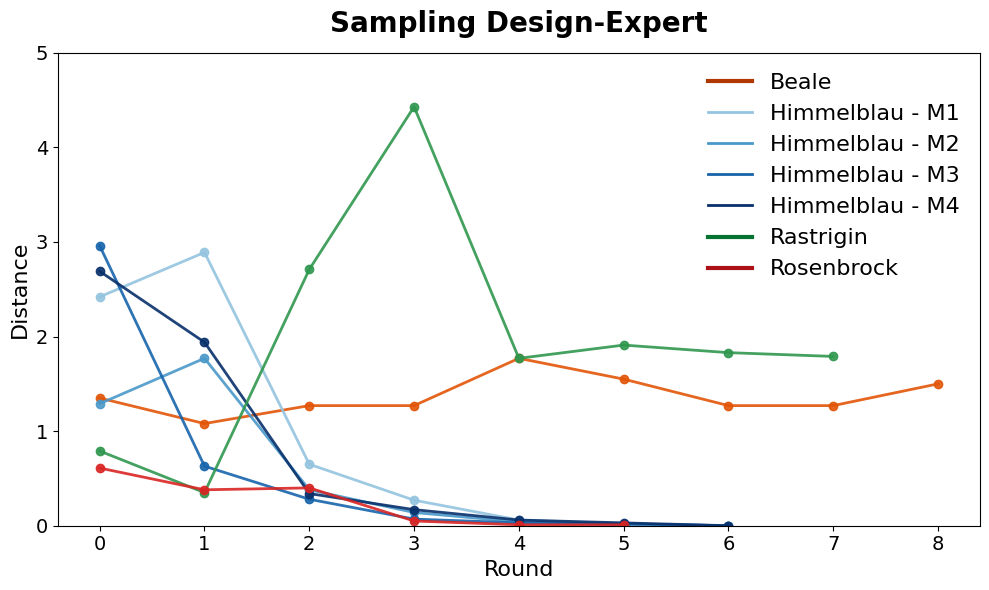

In [30]:
def plot_sampling_all(final_table):

    final_table['Round'] = pd.to_numeric(final_table['Round'], errors='coerce')
    functions = final_table['Function'].unique()

    plt.figure(figsize=(10, 6))
    
    cmap_map = {
        "Himmelblau": plt.cm.Blues,
        "Rosenbrock": plt.cm.Reds,
        "Rastrigin": plt.cm.Greens,
        "Beale": plt.cm.Oranges
    }

    legend_elements = []

    for func in functions:
        df = final_table[final_table['Function'] == func].copy()
        df = df.sort_values('Round')

        dist_cols = [col for col in df.columns if col.startswith('Distance_M')]

        cmap = cmap_map.get(func, plt.cm.viridis)
        
        if func == "Himmelblau":
            colors = cmap(np.linspace(0.4, 1, len(dist_cols))) 
        else:
            colors = cmap(np.linspace(0.7, 1, len(dist_cols)))  

        for i, col in enumerate(dist_cols):
            if df[col].notna().any():
                plt.plot(
                    df['Round'],
                    df[col],
                    marker='o',
                    markersize=6,
                    linestyle='-',
                    linewidth=2,
                    color=colors[i],
                    alpha=0.9
                )

                if func == "Himmelblau":
                    legend_elements.append(
                        Line2D([0], [0], color=colors[i], lw=2, label=f"{func} - M{i+1}")
                    )


        if func != "Himmelblau":
            legend_elements.append(
                Line2D([0], [0], color=cmap(0.85), lw=3, label=func)
            )


    plt.title('Sampling Design-Expert', fontweight='bold', fontsize=20, pad=15)
    plt.xlabel('Round', fontsize=16)
    plt.ylabel('Distance', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.ylim(0,5)

    plt.legend(handles=legend_elements, frameon=False, fontsize=16)
    #plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("Sampling_ALL.png", dpi=300)
    plt.show()
    
plot_sampling_all(final_table)

### Plot fitting all functions

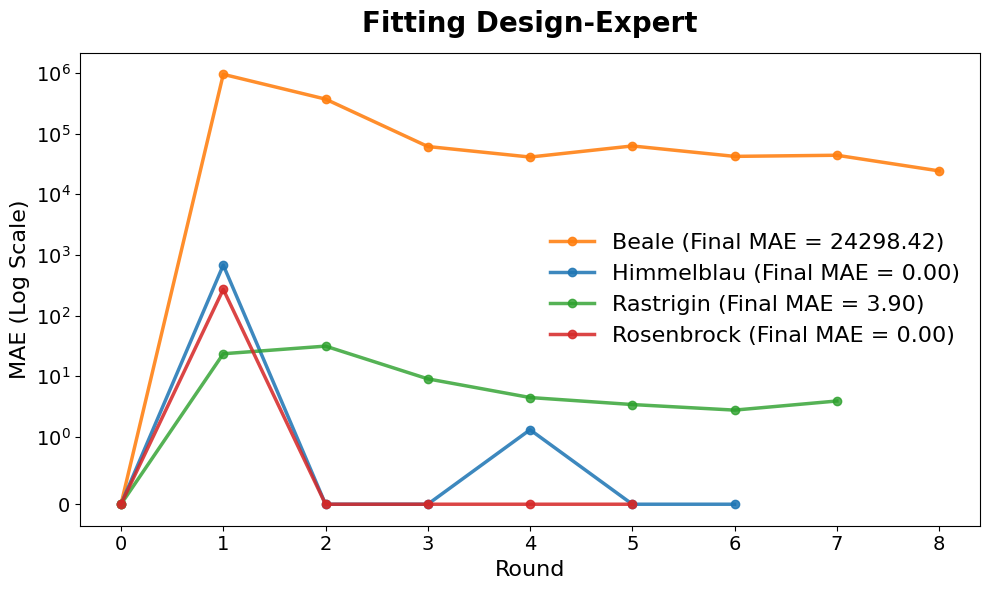

In [29]:
def plot_fitting_all(final_table):
    
    final_table['Round'] = pd.to_numeric(final_table['Round'], errors='coerce')
    functions = final_table['Function'].unique()

    colors = {
        "Rosenbrock": "#d62727dc",
        "Rastrigin": "#2ca02cce",
        "Himmelblau": "#1f76b4dd",
        "Beale": "#ff7e0edf"
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for func in functions:
        df = final_table[final_table['Function'] == func].copy()
        df = df.sort_values('Round')

        final_mae = df['MAE'].iloc[-1]

        ax.plot(
            df['Round'],
            df['MAE'],
            marker='o',
            markersize=6,
            linewidth=2.5,
            color=colors.get(func, None),
            label=f"{func} (Final MAE = {final_mae:.2f})"
        )

    ax.set_title('Fitting Design-Expert', fontsize=20, fontweight='bold', pad=15)
    ax.set_xlabel('Round', fontsize=16)
    ax.set_ylabel('MAE (Log Scale)', fontsize=16)

    
    ax.set_yscale('symlog', linthresh=1.0)

    rounds = sorted(final_table['Round'].dropna().unique())
    ax.set_xticks(rounds)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    #ax.grid(True, which="both", linestyle='--', alpha=0.4)
    
    ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16, loc='best')

    plt.tight_layout()
    plt.savefig("Fitting_ALL.png", dpi=300)
    plt.show()
    plt.close()
plot_fitting_all(final_table)

----------------------------------------------------------------